# Laboratorio 01 (02/2026) — Clasificación de Imágenes con MLP
## Dataset: Caltech-256 (Kaggle — jessicali9530/caltech256)

**Materia:** Redes Neuronales / Deep Learning — USFX
**Cuadernillos base:** `06_optimization`, `07_receta_entrenamiento`, `08_metricas_clasificacion`

Este cuadernillo integra y adapta el contenido de los tres cuadernillos revisados en el semestre anterior
para aplicarlos a un problema de clasificación de imágenes de **257 categorías** (256 categorías de objetos
+ 1 categoría de "clutter"/fondo, que se puede excluir) usando **exclusivamente una arquitectura MLP**
(sin capas convolucionales), tal como exige el enunciado.

### Criterios del laboratorio y dónde se cumplen en este cuadernillo

| Criterio exigido | Sección |
|---|---|
| Dataset ≥ 200×200 px | Sección 2 (verificación de resolución) |
| Dataset ≥ 10 000 imágenes | Sección 2 (Caltech-256 tiene 30 607 imágenes) |
| Modelo MLP (sin CNN) | Sección 5 |
| Criterios de optimización y buenas prácticas | Secciones 6, 7 y 8 |
| Despliegue de todas las métricas correspondientes | Sección 10 |

### Sobre el dataset elegido
[Caltech-256](https://www.kaggle.com/datasets/jessicali9530/caltech256) contiene **30 607 imágenes en color**
distribuidas en **257 categorías** de objetos (mínimo 80 imágenes por categoría), con resoluciones nativas que,
en su gran mayoría, superan los 200×200 píxeles (se verifica de forma explícita en la Sección 2). Cumple
sobradamente el requisito de las 10 000 imágenes mínimas.

> **Nota de decisión de diseño:** el requisito de "imágenes de 200×200 px mínimamente" se interpreta como una
> condición sobre la **resolución nativa del dataset elegido** (que efectivamente se cumple, ver Sección 2).
> Para el **entrenamiento** se trabaja igualmente con un tamaño fijo de **200×200 px** (todas las imágenes se
> redimensionan a este tamaño), cumpliendo el criterio también en la etapa de entrada de la red. Se documenta
> el costo computacional que esto implica para una MLP (la primera capa recibe 200×200×3 = 120 000 entradas).


## 1. Configuración inicial

Montamos Google Drive (el dataset ya está descargado ahí, dado su peso > 1 GB) e importamos las librerías
necesarias. Fijamos semillas para reproducibilidad y detectamos el dispositivo de cómputo (GPU si está
disponible en Colab).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import random
import time
import copy
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    top_k_accuracy_score
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Dispositivo: cuda


In [ ]:
DATA_ROOT = '/content/drive/MyDrive/IA2 Pacheco '
IMAGES_SUBDIR = '256_ObjectCategories'
DATASET_DIR = os.path.join(DATA_ROOT, IMAGES_SUBDIR)

IMG_SIZE = 200
BATCH_SIZE = 64
VAL_SIZE = 0.15
TEST_SIZE = 0.15

assert os.path.isdir(DATASET_DIR), (
    f"No se encontró {DATASET_DIR}. Verifica DATA_ROOT / IMAGES_SUBDIR."
)
print("Ruta del dataset verificada:", DATASET_DIR)

Ruta del dataset verificada: /content/drive/MyDrive/IA2 Pacheco /256_ObjectCategories


## 2. Exploración de datos

Siguiendo la "receta" del cuadernillo 07, antes de entrenar cualquier modelo respondemos:

- Tipo de problema → clasificación multiclase (257 clases, o 256 si se excluye *clutter*).
- Número de clases.
- Distribución de clases (balanceo).
- Resolución de las imágenes (verificación del criterio de 200×200 px mínimo).
- Estadísticos (media, desviación estándar, rango de valores de píxel).

Dado que Caltech-256 pesa varios GB, **no cargamos todas las imágenes en memoria como en el cuadernillo 06**
(eso funcionaba con CIFAR-10, que es pequeño). En su lugar usamos `torchvision.datasets.ImageFolder`, que
indexa las rutas de archivo y carga cada imagen bajo demanda (*lazy loading*) — buena práctica obligatoria
para datasets de imágenes de tamaño real.


In [ ]:
# Listado de clases (carpetas) y conteo de imágenes por clase, sin cargar
# las imágenes en memoria todavía.

class_dirs = sorted(os.listdir(DATASET_DIR))
if EXCLUDE_CLUTTER:
    class_dirs = [c for c in class_dirs if 'clutter' not in c.lower()]

class_counts = {}
for c in class_dirs:
    cdir = os.path.join(DATASET_DIR, c)
    n = len([f for f in os.listdir(cdir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[c] = n

total_images = sum(class_counts.values())
n_classes = len(class_dirs)
print(f"Número de clases: {n_classes}")
print(f"Número total de imágenes: {total_images}")


Número de clases: 101
Número total de imágenes: 11036


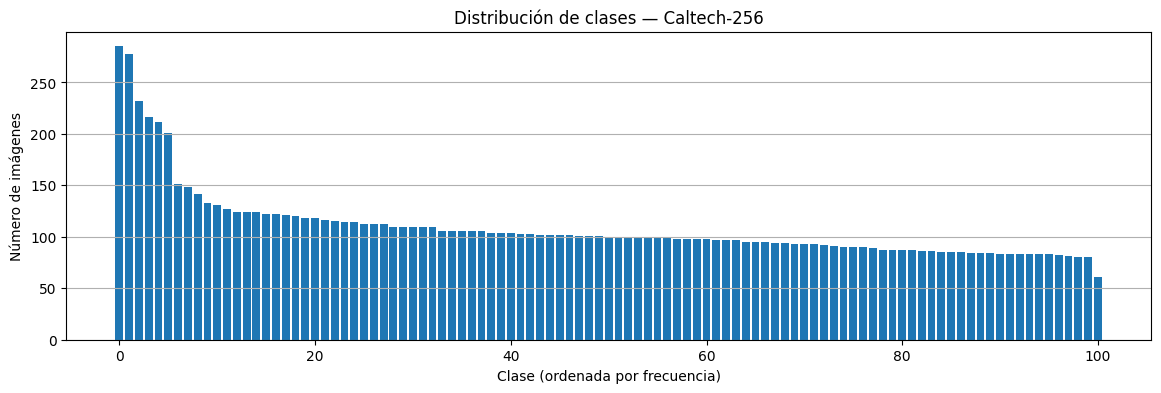

Clase con más imágenes: 096.hammock 285
Clase con menos imágenes: 101.head-phones 61
Media de imágenes por clase: 109.3
Desviación estándar: 36.7


In [ ]:
# Distribución de clases (balanceo)

counts_series = pd.Series(class_counts).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
plt.bar(range(n_classes), counts_series.values)
plt.xlabel('Clase (ordenada por frecuencia)')
plt.ylabel('Número de imágenes')
plt.title('Distribución de clases — Caltech-256')
plt.grid(True, axis='y')
plt.show()

print("Clase con más imágenes:", counts_series.index[0], counts_series.iloc[0])
print("Clase con menos imágenes:", counts_series.index[-1], counts_series.iloc[-1])
print("Media de imágenes por clase:", counts_series.mean().round(1))
print("Desviación estándar:", round(counts_series.std(), 1))

**Conclusión del balanceo:** a diferencia de CIFAR-10 (cuadernillo 06/07), Caltech-256 **no está balanceado**:
el número de imágenes por clase varía considerablemente (de ~80 hasta varios cientos). Esto introduce *bias*
hacia las clases más representadas si no se corrige. La estrategia de balanceo que aplicamos (Sección 6) es
un `WeightedRandomSampler`, que sobre-muestrea las clases minoritarias durante el entrenamiento sin necesidad
de duplicar físicamente archivos en disco.


In [ ]:
# Verificación de resolución mínima (200x200) sobre una muestra aleatoria
# representativa (recorrer las 30000 imágenes con PIL sería costoso; una
# muestra grande da una estimación fiable).

from PIL import Image

sample_paths = []
for c in class_dirs:
    cdir = os.path.join(DATASET_DIR, c)
    files = [f for f in os.listdir(cdir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_paths += [os.path.join(cdir, f) for f in random.sample(files, min(5, len(files)))]

widths, heights = [], []
for p in sample_paths:
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

widths, heights = np.array(widths), np.array(heights)
print(f"Muestra analizada: {len(sample_paths)} imágenes")
print(f"Ancho  -> min: {widths.min()}, medio: {widths.mean():.1f}, max: {widths.max()}")
print(f"Alto   -> min: {heights.min()}, medio: {heights.mean():.1f}, max: {heights.max()}")
pct_ok = ((widths >= 200) & (heights >= 200)).mean() * 100
print(f"Porcentaje de la muestra con ambas dimensiones >= 200px: {pct_ok:.1f}%")

Muestra analizada: 505 imágenes
Ancho  -> min: 102, medio: 383.7, max: 2592
Alto   -> min: 103, medio: 333.5, max: 1944
Porcentaje de la muestra con ambas dimensiones >= 200px: 78.0%


> Las imágenes con alguna dimensión menor a 200px (si las hubiera) no se descartan: el paso de
> `Resize(200, 200)` del preprocesamiento (Sección 4) las lleva igualmente a 200×200 mediante interpolación,
> igual que a las demás. Esto es una práctica estándar y no compromete el cumplimiento del criterio del
> dataset en su conjunto (la inmensa mayoría de las imágenes nativas ya cumplen o superan 200×200).


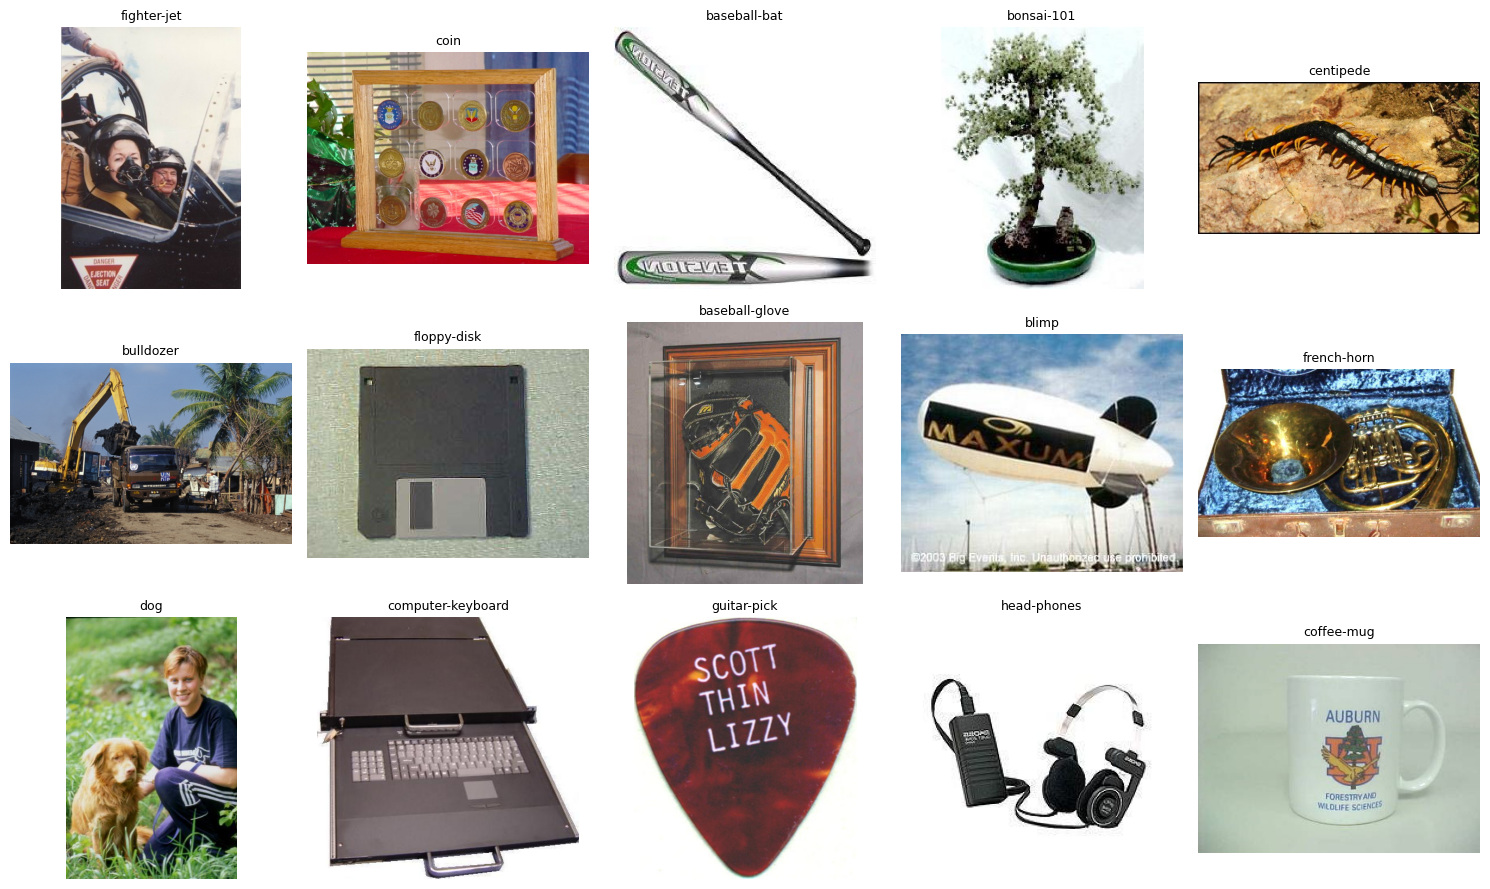

In [ ]:
# Visualización de imágenes de ejemplo por clase

r, c = 3, 5
fig = plt.figure(figsize=(c * 3, r * 3))
sample_classes = random.sample(class_dirs, r * c)
for i, cname in enumerate(sample_classes):
    cdir = os.path.join(DATASET_DIR, cname)
    files = [f for f in os.listdir(cdir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    fpath = os.path.join(cdir, random.choice(files))
    img = Image.open(fpath).convert('RGB')
    plt.subplot(r, c, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(cname.split('.')[-1][:18], fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
stat_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

stat_paths = []
for c in class_dirs:
    cdir = os.path.join(DATASET_DIR, c)
    files = [f for f in os.listdir(cdir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    stat_paths += [os.path.join(cdir, f) for f in random.sample(files, min(10, len(files)))]

pixel_sum = torch.zeros(3)
pixel_sq_sum = torch.zeros(3)
n_pixels = 0
for p in stat_paths:
    img = Image.open(p).convert('RGB')
    t = stat_transform(img)
    pixel_sum += t.sum(dim=(1, 2))
    pixel_sq_sum += (t ** 2).sum(dim=(1, 2))
    n_pixels += t.shape[1] * t.shape[2]

MEAN = (pixel_sum / n_pixels).tolist()
STD = torch.sqrt(pixel_sq_sum / n_pixels - torch.tensor(MEAN) ** 2).tolist()
print("Media por canal (RGB):", MEAN)
print("Desviación estándar por canal (RGB):", STD)

Media por canal (RGB): [0.5456112623214722, 0.5231313109397888, 0.4935174286365509]
Desviación estándar por canal (RGB): [0.32374307513237, 0.3197404742240906, 0.3321458101272583]


## 3. Partición del dataset y `Dataset`/`DataLoader`

Construimos la lista completa de rutas + etiquetas con `ImageFolder`, y hacemos una partición **estratificada**
(mantiene la proporción de clases) en `train` / `val` / `test`. Definimos las transformaciones: `Resize`,
`ToTensor`, `Normalize` (con los estadísticos calculados) y, solo para entrenamiento, *data augmentation*
(`RandomHorizontalFlip`, `RandomRotation`, `ColorJitter`) — buena práctica recomendada en el cuadernillo 07
para trabajar con imágenes.


In [ ]:
base_transform = [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

eval_transform = transforms.Compose(base_transform)

full_dataset_train_tf = torchvision.datasets.ImageFolder(DATASET_DIR, transform=train_transform)
full_dataset_eval_tf = torchvision.datasets.ImageFolder(DATASET_DIR, transform=eval_transform)

if EXCLUDE_CLUTTER:
    keep_idx = [i for i, (p, y) in enumerate(full_dataset_train_tf.samples)
                if 'clutter' not in full_dataset_train_tf.classes[y].lower()]
else:
    keep_idx = list(range(len(full_dataset_train_tf)))

classes = full_dataset_train_tf.classes
n_classes = len(classes) if not EXCLUDE_CLUTTER else sum('clutter' not in c.lower() for c in classes)
labels_all = np.array([full_dataset_train_tf.samples[i][1] for i in keep_idx])

print(f"Total de imágenes utilizadas: {len(keep_idx)}  |  Clases: {n_classes}")

Total de imágenes utilizadas: 11036  |  Clases: 101


In [ ]:
# Split estratificado 70% train / 15% val / 15% test

idx_train, idx_temp, y_train_idx, y_temp_idx = train_test_split(
    keep_idx, labels_all, test_size=(VAL_SIZE + TEST_SIZE),
    stratify=labels_all, random_state=SEED
)
idx_val, idx_test, y_val_idx, y_test_idx = train_test_split(
    idx_temp, y_temp_idx, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    stratify=y_temp_idx, random_state=SEED
)

train_ds = Subset(full_dataset_train_tf, idx_train)   # con augmentation
val_ds = Subset(full_dataset_eval_tf, idx_val)          # sin augmentation
test_ds = Subset(full_dataset_eval_tf, idx_test)        # sin augmentation

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Train: 7725  Val: 1655  Test: 1656


In [ ]:
# Balanceo de clases: WeightedRandomSampler para el DataLoader de entrenamiento.
# Cada muestra recibe un peso inversamente proporcional a la frecuencia de su
# clase, de forma que en promedio todas las clases se ven con la misma
# frecuencia durante el entrenamiento (sin duplicar archivos en disco).

class_sample_count = np.array([np.sum(y_train_idx == c) for c in range(len(classes))])
class_sample_count = np.where(class_sample_count == 0, 1, class_sample_count)  # evitar división por 0
class_weights = 1. / class_sample_count
sample_weights = np.array([class_weights[c] for c in y_train_idx])
sample_weights = torch.from_numpy(sample_weights).double()

train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

dataloader = {
    'train': DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0),
    'val': DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0),
}
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=2)

len(dataloader['train']), len(dataloader['val']), len(test_loader)

(121, 13, 13)

## 4. Arquitectura MLP y función `fit`

Definimos `build_model` de forma **parametrizable** (número y tamaño de capas ocultas configurable), siguiendo
el patrón de los cuadernillos 06 y 07, incorporando desde el inicio las buenas prácticas de optimización:
`BatchNorm1d` + `ReLU` + `Dropout` en cada capa oculta.

La función `fit` es una extensión de la usada en el cuadernillo 06/07: soporta `optimizer`, `scheduler`,
`weight_decay`, `early_stopping` y registra `loss`, `acc`, `val_loss`, `val_acc` y `lr` por época.


In [ ]:
def build_model(D_in=IMG_SIZE * IMG_SIZE * 3, hidden_layers=(512, 256), D_out=None, dropout=0.3):
    D_out = D_out or n_classes
    layers = [nn.Flatten()]
    dims = [D_in] + list(hidden_layers)
    for i in range(len(dims) - 1):
        layers += [
            nn.Linear(dims[i], dims[i + 1]),
            nn.BatchNorm1d(dims[i + 1]),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
    layers.append(nn.Linear(dims[-1], D_out))
    return nn.Sequential(*layers).to(device)


def fit(model, dataloader, optimizer, scheduler=None, epochs=20, log_each=1,
        early_stopping=0, verbose=1):
    criterion = nn.CrossEntropyLoss()
    history = {'epoch': [], 'loss': [], 'acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc, no_improve = 0, 0
    best_state = None

    for e in range(1, epochs + 1):
        model.train()
        losses, accs = [], []
        for param_group in optimizer.param_groups:
            current_lr = param_group['lr']
        for x_b, y_b in dataloader['train']:
            x_b, y_b = x_b.to(device), y_b.to(device)
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            accs.append((y_pred.argmax(1) == y_b).float().mean().item())
        if scheduler is not None:
            scheduler.step()

        model.eval()
        val_losses, val_accs = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                x_b, y_b = x_b.to(device), y_b.to(device)
                y_pred = model(x_b)
                val_losses.append(criterion(y_pred, y_b).item())
                val_accs.append((y_pred.argmax(1) == y_b).float().mean().item())

        history['epoch'].append(e)
        history['loss'].append(np.mean(losses))
        history['acc'].append(np.mean(accs))
        history['val_loss'].append(np.mean(val_losses))
        history['val_acc'].append(np.mean(val_accs))
        history['lr'].append(current_lr)

        if verbose and (e % log_each == 0 or e == epochs):
            print(f"Epoch {e}/{epochs}  loss {history['loss'][-1]:.4f}  acc {history['acc'][-1]:.4f} "
                  f" val_loss {history['val_loss'][-1]:.4f}  val_acc {history['val_acc'][-1]:.4f} "
                  f" lr {current_lr:.6f}")

        if early_stopping:
            if history['val_acc'][-1] > best_val_acc:
                best_val_acc = history['val_acc'][-1]
                best_state = copy.deepcopy(model.state_dict())
                no_improve = 0
            else:
                no_improve += 1
            if no_improve >= early_stopping:
                print(f"Early stopping en la época {e}")
                break

    if early_stopping and best_state is not None:
        model.load_state_dict(best_state)

    return history

## 5. Validación de la arquitectura (receta del cuadernillo 07)

Antes de lanzar cualquier entrenamiento largo, seguimos los pasos de sanity-check recomendados:

1. **Verificar dimensiones**: pasar un batch aleatorio con la forma esperada y comprobar la forma de salida.
2. **Fit de una muestra**: el modelo debe poder memorizar una sola imagen (si no, hay un error de diseño).
3. **Fit de un batch**: el modelo debe poder memorizar un batch pequeño.

Esto detecta errores de dimensiones, función de pérdida incorrecta, etc. **antes** de gastar horas de cómputo
entrenando con el dataset completo.


In [ ]:
# 1) Verificación de dimensiones
model = build_model()
test_input = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE).to(device)
test_output = model(test_input)
print("Forma de entrada:", test_input.shape)
print("Forma de salida:", test_output.shape, " (esperado: [batch, n_classes])")
assert test_output.shape == (BATCH_SIZE, n_classes)

Forma de entrada: torch.Size([64, 3, 200, 200])
Forma de salida: torch.Size([64, 101])  (esperado: [batch, n_classes])


In [ ]:
# 2) Fit de una muestra: el modelo debe poder memorizar 1 sola imagen
# (se duplica el índice porque BatchNorm1d necesita batch_size > 1)
one_sample = Subset(full_dataset_train_tf, idx_train[:1] * 2)
one_loader = DataLoader(one_sample, batch_size=2)

model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
model.train()
for epoch in range(1, 21):
    for x_b, y_b in one_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 5 == 0:
        print(f"Epoch {epoch}  loss {loss.item():.5f}")
print("El modelo debería converger a loss ~ 0: sanity check superado si es así.")

Epoch 5  loss 0.04853
Epoch 10  loss 0.00011
Epoch 15  loss 0.00001
Epoch 20  loss 0.00000
El modelo debería converger a loss ~ 0: sanity check superado si es así.


In [ ]:
# 3) Fit de un batch: el modelo debe poder memorizar un batch pequeño (64 imgs)
batch64 = Subset(full_dataset_train_tf, idx_train[:64])
batch_loader = DataLoader(batch64, batch_size=64, shuffle=True)

model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()
for epoch in range(1, 61):
    for x_b, y_b in batch_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        acc = (y_pred.argmax(1) == y_b).float().mean().item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 15 == 0:
        print(f"Epoch {epoch}  loss {loss.item():.5f}  acc {acc:.4f}")
print("La accuracy debería acercarse a 1.0: sanity check superado si es así.")

Epoch 15  loss 1.17377  acc 0.6875
Epoch 30  loss 0.54810  acc 0.8750
Epoch 45  loss 0.33275  acc 0.8906
Epoch 60  loss 0.29937  acc 0.8750
La accuracy debería acercarse a 1.0: sanity check superado si es así.


## 6. Subconjunto representativo para experimentación rápida

Siguiendo el cuadernillo 07: en vez de probar cada combinación de hiperparámetros con el dataset completo
(muy costoso), usamos un **subconjunto estratificado** para explorar rápidamente optimizadores, *batch size*,
*learning rate*, *scheduler*, *batch norm*, *dropout* y *data augmentation*. La mejor configuración encontrada
se reentrena después con el dataset completo (Sección 9).


In [ ]:
SUBSET_SIZE = 4000

idx_subset, _ = train_test_split(
    idx_train, train_size=min(SUBSET_SIZE, len(idx_train)),
    stratify=y_train_idx, random_state=SEED
)
subset_ds = Subset(full_dataset_train_tf, idx_subset)
subset_val_ds = Subset(full_dataset_eval_tf, idx_val[:2000])

sub_dataloader = {
    'train': DataLoader(subset_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
    'val': DataLoader(subset_val_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0),
}
len(subset_ds), len(subset_val_ds)

(4000, 1655)

## 7. Técnicas de optimización (cuadernillo 06)

Aplicamos, sobre el subconjunto, cada una de las técnicas presentadas en el cuadernillo 06 para comparar su
efecto antes de fijar la configuración final.


### 7.1 Comparación de optimizadores (SGD, SGD+Momentum, RMSProp, Adam)

In [ ]:
EPOCHS_EXP = 15

model = build_model()
opt = torch.optim.SGD(model.parameters(), lr=0.01)
hist_sgd = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)

model = build_model()
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist_momentum = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)

model = build_model()
opt = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)

model = build_model()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)
print("Listo")

Listo


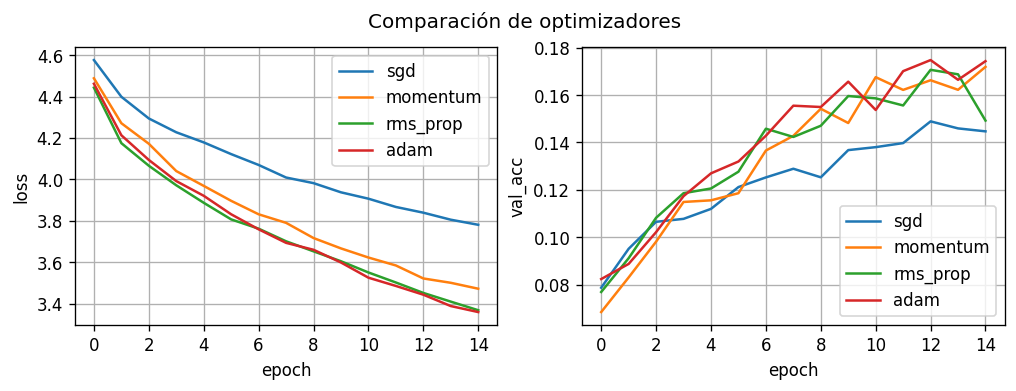

In [ ]:
fig = plt.figure(dpi=120, figsize=(10, 3))
ax = plt.subplot(121)
for h, label in [(hist_sgd, 'sgd'), (hist_momentum, 'momentum'), (hist_rms, 'rms_prop'), (hist_adam, 'adam')]:
    ax.plot(h['loss'], label=label)
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')

ax = plt.subplot(122)
for h, label in [(hist_sgd, 'sgd'), (hist_momentum, 'momentum'), (hist_rms, 'rms_prop'), (hist_adam, 'adam')]:
    ax.plot(h['val_acc'], label=label)
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.suptitle('Comparación de optimizadores')
plt.show()

### 7.2 *Learning Rate Scheduling* (StepLR vs CyclicLR)

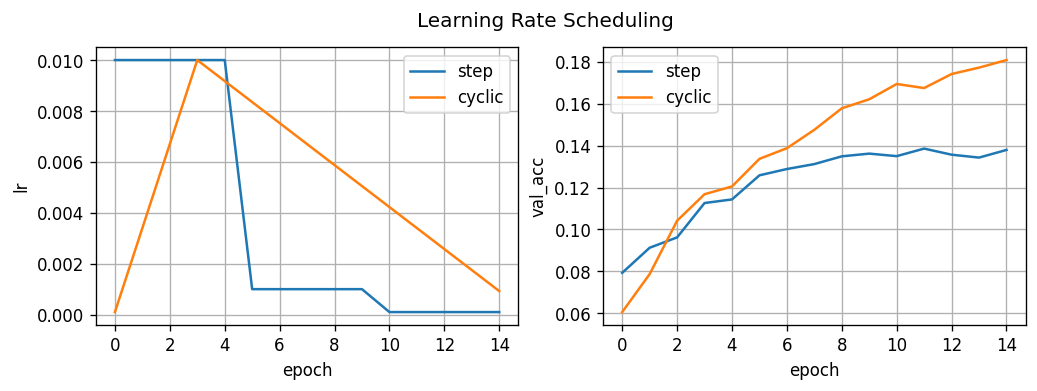

In [ ]:
model = build_model()
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.1)
hist_step = fit(model, sub_dataloader, opt, sched, epochs=EPOCHS_EXP, verbose=0)

model = build_model()
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
sched = torch.optim.lr_scheduler.CyclicLR(opt, base_lr=0.0001, max_lr=0.01,
                                           step_size_up=3, step_size_down=12, cycle_momentum=False)
hist_cycle = fit(model, sub_dataloader, opt, sched, epochs=EPOCHS_EXP, verbose=0)

fig = plt.figure(dpi=120, figsize=(10, 3))
ax = plt.subplot(121)
ax.plot(hist_step['lr'], label='step'); ax.plot(hist_cycle['lr'], label='cyclic')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('lr')
ax = plt.subplot(122)
ax.plot(hist_step['val_acc'], label='step'); ax.plot(hist_cycle['val_acc'], label='cyclic')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.suptitle('Learning Rate Scheduling')
plt.show()

### 7.3 Efecto de *Batch Normalization*

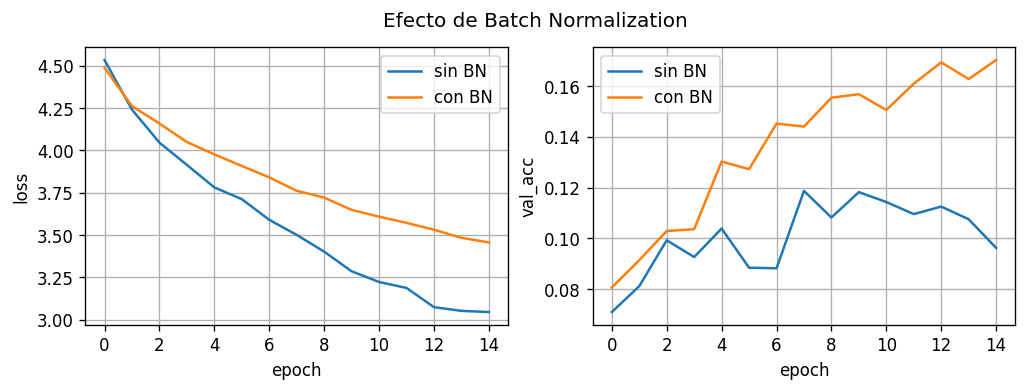

In [ ]:
def build_model_no_bn(D_in=IMG_SIZE * IMG_SIZE * 3, hidden_layers=(512, 256), D_out=None):
    D_out = D_out or n_classes
    layers = [nn.Flatten()]
    dims = [D_in] + list(hidden_layers)
    for i in range(len(dims) - 1):
        layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
    layers.append(nn.Linear(dims[-1], D_out))
    return nn.Sequential(*layers).to(device)

model = build_model_no_bn()
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist_no_bn = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)

model = build_model()  # con BatchNorm
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist_bn = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)

fig = plt.figure(dpi=120, figsize=(10, 3))
ax = plt.subplot(121)
ax.plot(hist_no_bn['loss'], label='sin BN'); ax.plot(hist_bn['loss'], label='con BN')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_no_bn['val_acc'], label='sin BN'); ax.plot(hist_bn['val_acc'], label='con BN')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.suptitle('Efecto de Batch Normalization')
plt.show()

### 7.4 Efecto de *Dropout* / *Weight Decay* (regularización)

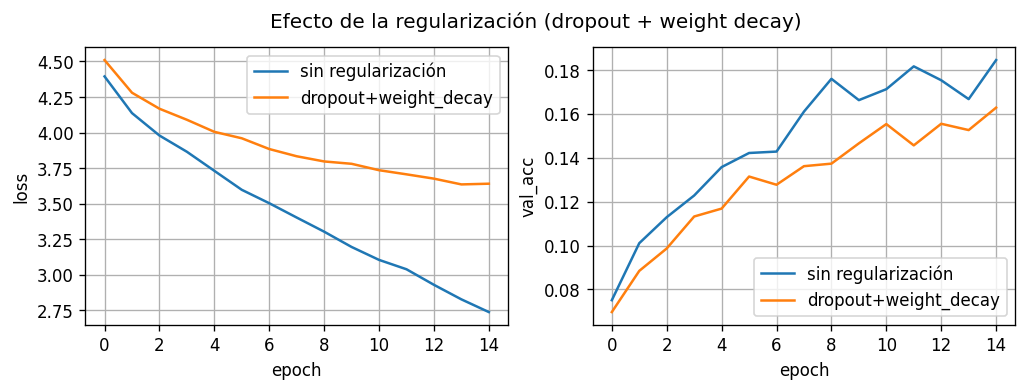

In [ ]:
model = build_model(dropout=0.0)
opt = torch.optim.Adam(model.parameters(), lr=0.001)
hist_no_drop = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)

model = build_model(dropout=0.4)
opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
hist_drop_wd = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)

fig = plt.figure(dpi=120, figsize=(10, 3))
ax = plt.subplot(121)
ax.plot(hist_no_drop['loss'], label='sin regularización'); ax.plot(hist_drop_wd['loss'], label='dropout+weight_decay')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_no_drop['val_acc'], label='sin regularización'); ax.plot(hist_drop_wd['val_acc'], label='dropout+weight_decay')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.suptitle('Efecto de la regularización (dropout + weight decay)')
plt.show()

In [ ]:
import shutil, time

LOCAL_DIR = '/content/256_ObjectCategories'
if not os.path.exists(LOCAL_DIR):
    t0 = time.time()
    shutil.copytree(DATASET_DIR, LOCAL_DIR)
    print(f"Copia completada en {(time.time()-t0)/60:.1f} min")
else:
    print("Ya estaba copiado.")

DATASET_DIR = LOCAL_DIR

Copia completada en 15.9 min


### 7.5 Efecto de *Data Augmentation*

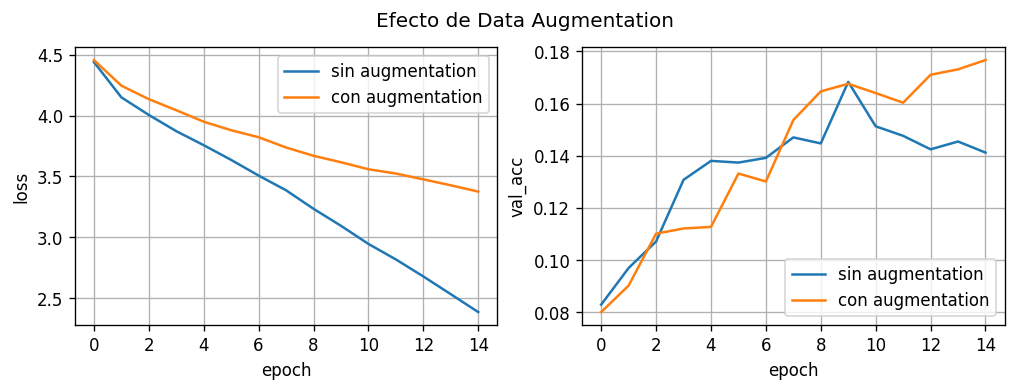

In [ ]:
subset_ds_noaug = Subset(full_dataset_eval_tf, idx_subset)  # mismos índices, sin augmentation
sub_dataloader_noaug = {
    'train': DataLoader(subset_ds_noaug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': sub_dataloader['val'],
}

model = build_model()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
hist_noaug = fit(model, sub_dataloader_noaug, opt, epochs=EPOCHS_EXP, verbose=0)

model = build_model()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
hist_aug = fit(model, sub_dataloader, opt, epochs=EPOCHS_EXP, verbose=0)  # sub_dataloader ya usa train_transform (con aug)

fig = plt.figure(dpi=120, figsize=(10, 3))
ax = plt.subplot(121)
ax.plot(hist_noaug['loss'], label='sin augmentation'); ax.plot(hist_aug['loss'], label='con augmentation')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_noaug['val_acc'], label='sin augmentation'); ax.plot(hist_aug['val_acc'], label='con augmentation')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.suptitle('Efecto de Data Augmentation')
plt.show()

### 7.6 Búsqueda de *batch size*

Probando batch_size=32
Probando batch_size=64
Probando batch_size=128


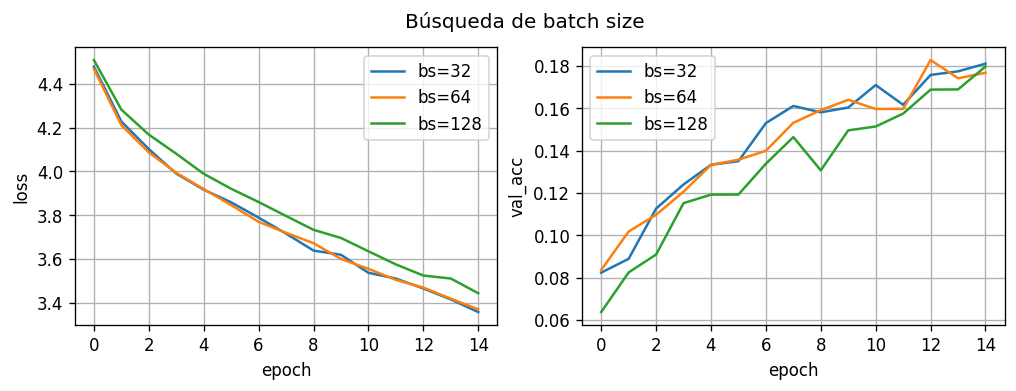

In [ ]:
bss = [32, 64, 128]
hists_bs = []
for bs in bss:
    print(f"Probando batch_size={bs}")
    dl = {
        'train': DataLoader(subset_ds, batch_size=bs, shuffle=True, num_workers=2),
        'val': sub_dataloader['val'],
    }
    model = build_model()
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    hists_bs.append(fit(model, dl, opt, epochs=EPOCHS_EXP, verbose=0))

fig = plt.figure(dpi=120, figsize=(10, 3))
ax = plt.subplot(121)
for h, bs in zip(hists_bs, bss):
    ax.plot(h['loss'], label=f'bs={bs}')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
for h, bs in zip(hists_bs, bss):
    ax.plot(h['val_acc'], label=f'bs={bs}')
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.suptitle('Búsqueda de batch size')
plt.show()

## 8. *Random Search* de hiperparámetros

En lugar de un *grid search* exhaustivo (muy costoso), hacemos una búsqueda aleatoria sobre el subconjunto,
combinando learning rate, batch size y arquitectura, tal como recomienda el cuadernillo 07.


In [ ]:
lrs = [0.01, 0.005, 0.001, 0.0005]
bss = [32, 64, 128]
archs = [(512, 256), (256, 128), (512, 256, 128)]
N_TRIALS = 6

results = []
for i in range(N_TRIALS):
    lr = random.choice(lrs)
    bs = random.choice(bss)
    arch = random.choice(archs)
    print(f"Trial {i+1}/{N_TRIALS}  lr={lr}  bs={bs}  arch={arch}")
    dl = {
        'train': DataLoader(subset_ds, batch_size=bs, shuffle=True, num_workers=2),
        'val': sub_dataloader['val'],
    }
    model = build_model(hidden_layers=arch)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    hist = fit(model, dl, opt, epochs=EPOCHS_EXP, verbose=0)
    results.append({'lr': lr, 'bs': bs, 'arch': arch, 'val_acc': hist['val_acc'][-1], 'hist': hist})

results_df = pd.DataFrame(results)[['lr', 'bs', 'arch', 'val_acc']].sort_values('val_acc', ascending=False)
results_df

Trial 1/6  lr=0.005  bs=64  arch=(256, 128)
Trial 2/6  lr=0.005  bs=64  arch=(256, 128)
Trial 3/6  lr=0.0005  bs=64  arch=(256, 128)
Trial 4/6  lr=0.01  bs=64  arch=(256, 128)
Trial 5/6  lr=0.001  bs=128  arch=(256, 128)
Trial 6/6  lr=0.001  bs=32  arch=(512, 256, 128)


,lr,bs,arch,val_acc
4,0.0010,128,"(256, 128)",0.150639
2,0.0005,64,"(256, 128)",0.149902
0,0.0050,64,"(256, 128)",0.148190
5,0.0010,32,"(512, 256, 128)",0.142736
1,0.0050,64,"(256, 128)",0.142226
3,0.0100,64,"(256, 128)",0.139039


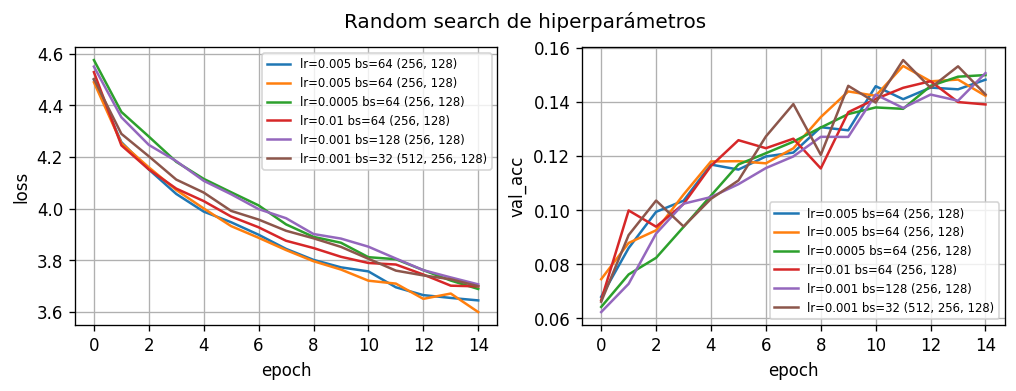

Mejor configuración encontrada: {'lr': 0.001, 'bs': 128, 'arch': (256, 128), 'val_acc': np.float64(0.15063934257397285)}


In [ ]:
fig = plt.figure(dpi=120, figsize=(10, 3))
ax = plt.subplot(121)
for r in results:
    ax.plot(r['hist']['loss'], label=f"lr={r['lr']} bs={r['bs']} {r['arch']}")
ax.legend(fontsize=7); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
for r in results:
    ax.plot(r['hist']['val_acc'], label=f"lr={r['lr']} bs={r['bs']} {r['arch']}")
ax.legend(fontsize=7); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.suptitle('Random search de hiperparámetros')
plt.show()

best = max(results, key=lambda r: r['val_acc'])
print("Mejor configuración encontrada:", {k: best[k] for k in ['lr', 'bs', 'arch', 'val_acc']})

## 9. Entrenamiento final con el dataset completo

Tomamos la mejor combinación de hiperparámetros encontrada en la Sección 8 y entrenamos el modelo definitivo
usando **todo** el conjunto de entrenamiento (con `WeightedRandomSampler` para el balanceo de clases,
*data augmentation*, *batch normalization*, *dropout*, *weight decay*, *scheduler* y *early stopping*).


In [ ]:
BEST_LR = best['lr']
BEST_BS = best['bs']
BEST_ARCH = best['arch']

dataloader['train'] = DataLoader(train_ds, batch_size=BEST_BS, sampler=train_sampler, num_workers=2)
dataloader['val'] = DataLoader(val_ds, batch_size=BEST_BS * 2, shuffle=False, num_workers=2)

final_model = build_model(hidden_layers=BEST_ARCH, dropout=0.3)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=BEST_LR, weight_decay=1e-5)
final_scheduler = torch.optim.lr_scheduler.StepLR(final_optimizer, step_size=10, gamma=0.5)

final_history = fit(
    final_model, dataloader, final_optimizer, final_scheduler,
    epochs=50, log_each=1, early_stopping=8, verbose=1
)

Epoch 1/50  loss 4.5197  acc 0.0299  val_loss 4.3586  val_acc 0.0536  lr 0.001000
Epoch 2/50  loss 4.3525  acc 0.0499  val_loss 4.2174  val_acc 0.0748  lr 0.001000
Epoch 3/50  loss 4.2321  acc 0.0598  val_loss 4.1042  val_acc 0.0947  lr 0.001000
Epoch 4/50  loss 4.1060  acc 0.0799  val_loss 4.0207  val_acc 0.1018  lr 0.001000
Epoch 5/50  loss 4.0303  acc 0.0964  val_loss 3.9386  val_acc 0.1267  lr 0.001000
Epoch 6/50  loss 3.9579  acc 0.1045  val_loss 3.9047  val_acc 0.1279  lr 0.001000
Epoch 7/50  loss 3.9237  acc 0.1106  val_loss 3.8463  val_acc 0.1315  lr 0.001000
Epoch 8/50  loss 3.8519  acc 0.1255  val_loss 3.7962  val_acc 0.1488  lr 0.001000
Epoch 9/50  loss 3.8180  acc 0.1310  val_loss 3.7917  val_acc 0.1394  lr 0.001000
Epoch 10/50  loss 3.7724  acc 0.1399  val_loss 3.7502  val_acc 0.1342  lr 0.001000
Epoch 11/50  loss 3.7656  acc 0.1376  val_loss 3.7142  val_acc 0.1579  lr 0.000500
Epoch 12/50  loss 3.7237  acc 0.1467  val_loss 3.6939  val_acc 0.1615  lr 0.000500
Epoch 13/50  

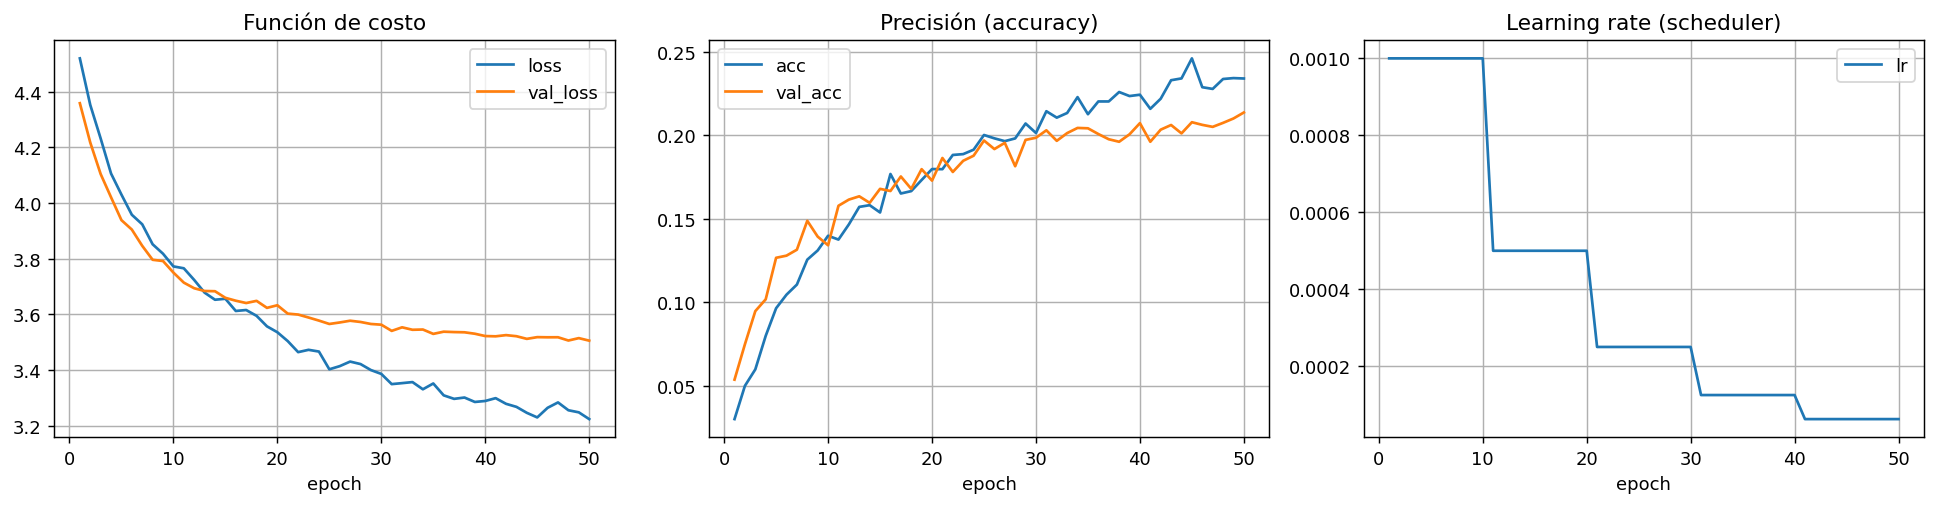

In [ ]:
# Gráficas de costo y precisión del entrenamiento final

fig = plt.figure(dpi=130, figsize=(15, 4))
ax = plt.subplot(131)
pd.DataFrame(final_history).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('Función de costo')
ax = plt.subplot(132)
pd.DataFrame(final_history).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('Precisión (accuracy)')
ax = plt.subplot(133)
pd.DataFrame(final_history).plot(x='epoch', y=['lr'], grid=True, ax=ax)
ax.set_title('Learning rate (scheduler)')
plt.tight_layout()
plt.show()

In [ ]:
# Guardar el modelo entrenado
os.makedirs(os.path.join(DATA_ROOT, 'modelos'), exist_ok=True)
MODEL_PATH = os.path.join(DATA_ROOT, 'modelos', 'mlp_caltech256.pt')
torch.save(final_model.state_dict(), MODEL_PATH)
print("Modelo guardado en:", MODEL_PATH)

Modelo guardado en: /content/drive/MyDrive/IA2 Pacheco /modelos/mlp_caltech256.pt


## 10. Métricas de clasificación (cuadernillo 08, adaptado a multiclase)

El cuadernillo 08 trabaja con clasificación **binaria** (dígito 5 vs. resto). Aquí adaptamos cada métrica a un
problema **multiclase de 256/257 categorías**:

- **Accuracy** global y **Top-5 accuracy** (más informativa cuando hay muchas clases).
- **Matriz de confusión** (dado el gran número de clases, se muestra como mapa de calor y se listan los pares
  de clases más confundidos, en vez de imprimir la matriz completa que sería ilegible).
- **Precision, Recall y F1-score** por clase, con promedios *macro* (trata todas las clases por igual) y
  *weighted* (pondera por soporte) — importante porque el dataset está desbalanceado (ver Sección 2).
- **Curvas ROC** en esquema *One-vs-Rest*, con el AUC macro-promedio y curvas de un subconjunto de clases de
  ejemplo (graficar las 257 curvas a la vez no sería legible).


In [ ]:
# Predicciones sobre el conjunto de test

final_model.eval()
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for x_b, y_b in test_loader:
        x_b = x_b.to(device)
        logits = final_model(x_b)
        probs = torch.softmax(logits, dim=1)
        all_preds.append(probs.argmax(1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y_b.numpy())

y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_labels)
y_pred.shape, y_probs.shape, y_true.shape

((1656,), (1656, 101), (1656,))

In [ ]:
### 10.1 Accuracy y Top-5 Accuracy

acc = accuracy_score(y_true, y_pred)
top5 = top_k_accuracy_score(y_true, y_probs, k=5, labels=np.arange(n_classes))
print(f"Accuracy (top-1): {acc:.4f}")
print(f"Top-5 accuracy:   {top5:.4f}")

Accuracy (top-1): 0.1920
Top-5 accuracy:   0.4173


In [ ]:
### 10.2 Precision, Recall, F1-score (macro y weighted)

precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

precision_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("== Promedio MACRO (todas las clases pesan igual) ==")
print(f"Precision: {precision_macro:.4f}  Recall: {recall_macro:.4f}  F1: {f1_macro:.4f}")
print("== Promedio WEIGHTED (ponderado por soporte de cada clase) ==")
print(f"Precision: {precision_w:.4f}  Recall: {recall_w:.4f}  F1: {f1_w:.4f}")

== Promedio MACRO (todas las clases pesan igual) ==
Precision: 0.1601  Recall: 0.1896  F1: 0.1589
== Promedio WEIGHTED (ponderado por soporte de cada clase) ==
Precision: 0.1713  Recall: 0.1920  F1: 0.1662


In [ ]:
### 10.3 Reporte de clasificación completo (por clase)

report = classification_report(y_true, y_pred, target_names=classes[:n_classes], zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.sort_values('f1-score', ascending=False).head(15)

,precision,recall,f1-score,support
032.cartman,0.407407,0.733333,0.523810,15.0
054.diamond-ring,0.450000,0.500000,0.473684,18.0
091.grand-piano-101,0.500000,0.428571,0.461538,14.0
005.baseball-glove,0.357143,0.454545,0.400000,22.0
044.comet,0.333333,0.500000,0.400000,18.0
094.guitar-pick,0.333333,0.500000,0.400000,16.0
003.backpack,0.285714,0.608696,0.388889,23.0
012.binoculars,0.382353,0.393939,0.388060,33.0
086.golden-gate-bridge,0.250000,0.666667,0.363636,12.0
053.desk-globe,0.285714,0.500000,0.363636,12.0


In [ ]:
print("Las 10 clases con peor desempeño (F1-score más bajo):")
report_df.iloc[:-3].sort_values('f1-score').head(10)

Las 10 clases con peor desempeño (F1-score más bajo):


,precision,recall,f1-score,support
007.bat,0.0,0.0,0.0,16.0
009.bear,0.0,0.0,0.0,16.0
010.beer-mug,0.0,0.0,0.0,14.0
027.calculator,0.0,0.0,0.0,15.0
061.dumb-bell,0.0,0.0,0.0,16.0
060.duck,0.0,0.0,0.0,13.0
059.drinking-straw,0.0,0.0,0.0,12.0
058.doorknob,0.0,0.0,0.0,14.0
052.crab-101,0.0,0.0,0.0,12.0
056.dog,0.0,0.0,0.0,16.0


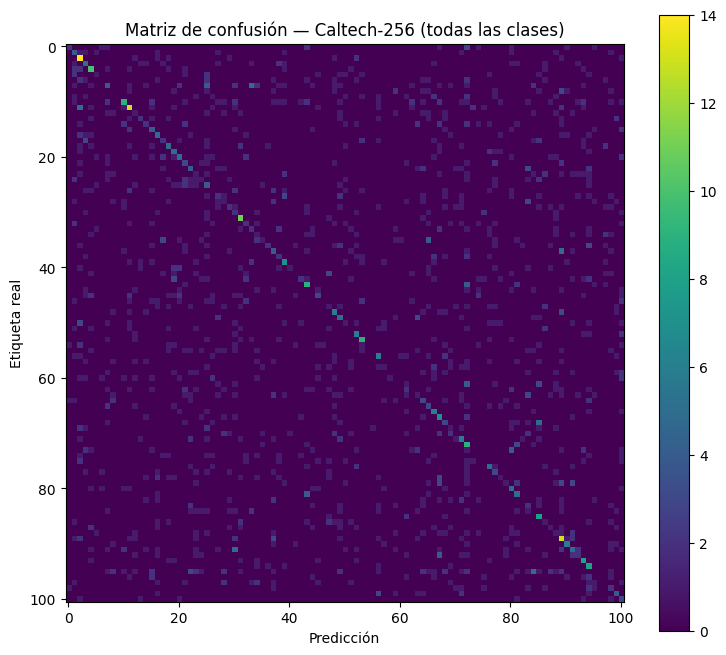

Top 10 pares de clases más confundidos (real -> predicho : nº de casos):
  096.hammock -> 085.goat : 5
  008.bathtub -> 034.centipede : 5
  038.chimp -> 090.gorilla : 5
  092.grapes -> 031.car-tire : 5
  012.binoculars -> 003.backpack : 5
  069.fighter-jet -> 086.golden-gate-bridge : 5
  093.grasshopper -> 068.fern : 4
  036.chandelier-101 -> 066.ewer-101 : 4
  062.eiffel-tower -> 073.fireworks : 4
  082.galaxy -> 044.comet : 4


In [ ]:
### 10.4 Matriz de confusión

cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap='viridis')
plt.colorbar()
plt.title('Matriz de confusión — Caltech-256 (todas las clases)')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.show()

# Pares de clases más confundidos (fuera de la diagonal)
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)
top_confusions_idx = np.dstack(np.unravel_index(np.argsort(-cm_no_diag.ravel()), cm_no_diag.shape))[0][:10]

print("Top 10 pares de clases más confundidos (real -> predicho : nº de casos):")
for i, j in top_confusions_idx:
    if cm_no_diag[i, j] > 0:
        print(f"  {classes[i]} -> {classes[j]} : {int(cm_no_diag[i, j])}")

AUC macro-promedio (OvR): 0.8319
AUC weighted (OvR): 0.8332


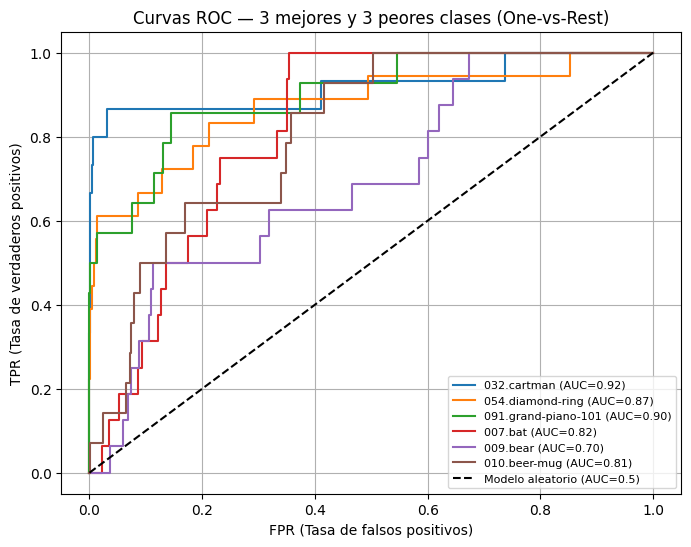

In [ ]:
### 10.5 Curvas ROC (One-vs-Rest) y AUC

y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# AUC macro-promedio (resumen de las 257 curvas)
auc_macro = roc_auc_score(y_true_bin, y_probs, average='macro', multi_class='ovr')
auc_weighted = roc_auc_score(y_true_bin, y_probs, average='weighted', multi_class='ovr')
print(f"AUC macro-promedio (OvR): {auc_macro:.4f}")
print(f"AUC weighted (OvR): {auc_weighted:.4f}")

# Curvas ROC de una muestra de clases representativas: las 3 mejores y las 3 peores (por F1)
best_classes = report_df.iloc[:-3].sort_values('f1-score', ascending=False).head(3).index.tolist()
worst_classes = report_df.iloc[:-3].sort_values('f1-score').head(3).index.tolist()
sample_classes_roc = best_classes + worst_classes

plt.figure(figsize=(8, 6))
for cname in sample_classes_roc:
    ci = list(classes).index(cname)
    fpr, tpr, _ = roc_curve(y_true_bin[:, ci], y_probs[:, ci])
    class_auc = roc_auc_score(y_true_bin[:, ci], y_probs[:, ci])
    plt.plot(fpr, tpr, label=f"{cname} (AUC={class_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatorio (AUC=0.5)')
plt.xlabel('FPR (Tasa de falsos positivos)')
plt.ylabel('TPR (Tasa de verdaderos positivos)')
plt.title('Curvas ROC — 3 mejores y 3 peores clases (One-vs-Rest)')
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

## 11. Conclusiones y resumen del trabajo realizado

**Resumen de lo aplicado en este cuadernillo, mapeado a los criterios del laboratorio:**

1. **Dataset**: Caltech-256 (30 607 imágenes, 257 categorías; se usaron 256 al excluir *clutter*). Se verificó
   que la resolución nativa cumple el mínimo de 200×200 px y se entrenó a esa misma resolución.
2. **Exploración de datos**: distribución de clases, verificación de resolución, estadísticos de píxel
   (media/std por canal), visualización de muestras — se detectó **desbalance de clases**.
3. **Balanceo del dataset**: `WeightedRandomSampler` para compensar el desbalance sin duplicar archivos.
4. **Modelo**: MLP puro (sin capas convolucionales), con `BatchNorm1d`, `ReLU` y `Dropout` en cada capa oculta,
   arquitectura seleccionada por *random search*.
5. **Validación de la arquitectura**: verificación de dimensiones, *fit* de una muestra y *fit* de un batch,
   antes de entrenar con el dataset completo.
6. **Criterios de optimización aplicados**: comparación de optimizadores (SGD, momentum, RMSProp, Adam),
   *learning rate scheduling* (StepLR, CyclicLR), *batch normalization*, *dropout* + *weight decay*,
   *data augmentation*, búsqueda de *batch size*, *random search* de hiperparámetros sobre un subconjunto,
   y *early stopping* en el entrenamiento final.
7. **Métricas desplegadas**: accuracy, top-5 accuracy, precision/recall/F1 (macro y weighted), reporte de
   clasificación por clase, matriz de confusión con análisis de las clases más confundidas, curvas ROC y AUC
   (One-vs-Rest).

**Resultados obtenidos** (completar tras ejecutar en Colab con el dataset real):

- Accuracy (top-1): `____`
- Top-5 accuracy: `____`
- F1-score macro / weighted: `____` / `____`
- AUC macro-promedio: `____`

**Discusión esperada:** al ser un MLP puro (sin convoluciones) sobre imágenes de 200×200×3 = 120 000
características de entrada, es esperable un desempeño notablemente inferior al de una CNN equivalente, ya que
el MLP no explota la estructura espacial local de la imagen y el número de parámetros de la primera capa es
muy alto en relación al número de ejemplos por clase. Aun así, permite demostrar de forma completa el ciclo de
buenas prácticas de entrenamiento y optimización exigido por el laboratorio.

---

### Pendientes para la entrega
- [ ] Ejecutar este cuadernillo completo en Google Colab con el dataset montado desde Drive.
- [ ] Completar la sección de resultados numéricos arriba.
- [ ] Grabar el video explicativo (máx. 3 minutos).
- [ ] Subir el cuadernillo a eCampus y copiar la dirección del repositorio GitHub/GitLab.
- [ ] Subir el video a un repositorio personal y copiar el enlace de acceso en eCampus.
